# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Argama Vanesa Nauli Sijabat
- **Email:** argamasijabat@mail.com
- **ID Dicoding:** CDCC010D6X2439

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren penjualan secara bulanan (Month-over-Month) sepanjang tahun 2017?
2. Bagaimana tingkat kepuasan pelanggan terhadap produk sepanjang tahun 2017?
3. Bagaimana pengaruh faktor operasional transaksi terhadap kepuasan pelanggan sepanjang tahun 2017?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
#@title customer_dataset

df_customer = pd.read_csv("customers_dataset.csv", delimiter=",")

df_customer.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
#@title order_payments_dataset

df_payments = pd.read_csv("order_payments_dataset.csv", delimiter=",")

df_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [4]:
#@title order_reviews_dataset

df_reviews = pd.read_csv("order_reviews_dataset.csv", delimiter=",")

df_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [5]:
#@title orders_dataset

df_orders = pd.read_csv("orders_dataset.csv", delimiter=",")

df_orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**

Dataset yang digunakan bersumber dari **E-Commerce Public Dataset** yang memiliki **9 file dengan format csv**. Pada notebook ini akan dilakukan analisis terhadap **4 file** yang meliputi
1. **customer_dataset** : berisi data pelanggan yang mencakup ID pelanggan, kode zip, nama kota tempat pelanggan, dan nama state tempat pelanggan.
2. **order_payments_dataset**: berisi ID pemesanan, metode pembayaran, dan nilai pembayaran.
3. **order_reviews_dataset**: berisi ID ulasan, ID pemesanan, nilai ulasan, timestamp ulasan, dan pesan ulasan.
4. **orders_dataset**: ID pemesanan, ID pelanggan, status pesanan, timestamp pemesanan, timestamp penyetujuan pesanan, timestamp pesanan diserahkan seller  ke ekspedisi, timestamp pesanan diterima pelanggan, dan perkiraan tanggal pesanan diterima  pelanggan.

Pemilihan file dilakukan agar analisis dapat dilakukan dengan fokus utama pada angka penjualan dan kepuasan pelanggan.


### Assessing Data

In [6]:
#@title assessing customer_dataset

df_customer.info()
print("Jumlah duplikasi: ", df_customer.duplicated().sum())
df_customer.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Jumlah duplikasi:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [7]:
#@title assessing order_payments_dataset

df_payments.info()
print("Jumlah duplikasi: ", df_payments.duplicated().sum())
df_payments.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
Jumlah duplikasi:  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [8]:
#@title assessing order_reviews_dataset

df_reviews.info()
print("Jumlah duplikasi: ", df_reviews.duplicated().sum())
df_reviews.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
Jumlah duplikasi:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [9]:
#@title assessing orders_dataset

df_orders.info()
print("Jumlah duplikasi: ", df_orders.duplicated().sum())
df_orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**

| Dataset | Missing Value | Duplikasi Data | Kesalahan Tipe Data | Nilai Mencurigakan |
|---|---|---|---|---|
| **customer_dataset** | Tidak ada | Tidak ada | `customer_zip_code_prefix` seharusnya bertipe *object/string*, bukan numerik | Tidak ada |
| **order_payments_dataset** | Tidak ada | Tidak ada | Tidak ada | `payment_sequential` maksimum 29, `payment_installments` minimum 0, dan `payment_value` minimum 0 |
| **order_reviews_dataset** | Ada pada `review_comment_title` dan `review_comment_message` | Tidak ada | Ada pada `review_creation_date` dan `review_answer_timestamp` | Tidak ada |
| **orders_dataset** | Ada pada `order_delivered_carrier_date` dan `order_delivered_customer_date` | Tidak ada | Kolom timestamp masih bertipe *object*, seharusnya *datetime* | Tidak ada |

### Cleaning Data

In [10]:
#@title cleaning customer_dataset

df_customer["customer_zip_code_prefix"] = df_customer["customer_zip_code_prefix"].astype("string")

df_customer.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  string
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(4), string(1)
memory usage: 3.8+ MB


In [11]:
#@title cleaning order_payment_dataset

#PAYMENT SEQUENTIAL
# cek distribusi payment_sequential tinggi
df_payments["payment_sequential"].value_counts().sort_index().tail(15)

# cari order dengan payment_sequential maksimum
max_seq_order = df_payments.groupby("order_id")["payment_sequential"].max().loc[lambda x: x == 29]
max_seq_order

# lihat detail order dengan payment_sequential = 29
order_seq_29 = max_seq_order.index[0]
df_payments[df_payments["order_id"] == order_seq_29].sort_values("payment_sequential")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
14321,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71
23074,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51
65641,fa65dad1b0e818e3ccc5cb0e39231352,3,voucher,1,2.95
9985,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16
28330,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66
29648,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02
82593,fa65dad1b0e818e3ccc5cb0e39231352,7,voucher,1,0.32
68853,fa65dad1b0e818e3ccc5cb0e39231352,8,voucher,1,26.02
17274,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08
19565,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86


In [12]:
#PAYMENT INSTALLMENTS
# jumlah record dengan payment_installments = 0
df_payments[df_payments["payment_installments"] == 0].shape

# payment type apa saja yang punya installment = 0
df_payments[df_payments["payment_installments"] == 0]["payment_type"].value_counts()

# lihat detail record dengan installment = 0
df_payments[df_payments["payment_installments"] == 0].sort_values("payment_type").head(20)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [13]:
# ubah semua payment_installments bernilai 0 menjadi 1
df_payments["payment_installments"] = df_payments["payment_installments"].replace(0, 1)

df_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853368,154.100380
std,0.706584,2.687034,217.494064
min,1.000000,1.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [14]:
#PAYMENT VALUE
# jumlah record dengan payment_value = 0
df_payments[df_payments["payment_value"] == 0].shape

# payment type untuk payment_value = 0
df_payments[df_payments["payment_value"] == 0]["payment_type"].value_counts()

# lihat detail payment_value = 0
df_payments[df_payments["payment_value"] == 0].sort_values("payment_type").head(20)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [15]:
# hapus record dengan payment_type = not_defined dan payment_value = 0
df_payments = df_payments[
    ~(
        (df_payments["payment_type"] == "not_defined") &
        (df_payments["payment_value"] == 0)
    )
]

df_payments.describe()

# lihat detail payment_value = 0
df_payments[df_payments["payment_value"] == 0].sort_values("payment_type").head(20)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [16]:
#@title cleaning order_reviews_dataset

# convert kolom tanggal ke datetime
review_datetime_cols = ["review_creation_date", "review_answer_timestamp"]

for col in review_datetime_cols:
    df_reviews[col] = pd.to_datetime(df_reviews[col])

# isi missing text review dengan placeholder
df_reviews["review_comment_title"] = df_reviews["review_comment_title"].fillna("No Title")
df_reviews["review_comment_message"] = df_reviews["review_comment_message"].fillna("No Review Comment")

In [17]:
#@title cleaning orders_dataset

# convert kolom tanggal pada orders_dataset ke datetime
orders_datetime_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for col in orders_datetime_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [18]:
# cek jumlah missing value per kolom
df_orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [19]:
# cek proporsi missing value (%)
(df_orders.isnull().sum() / len(df_orders) * 100).round(2)

,0
order_id,0.00
customer_id,0.00
order_status,0.00
order_purchase_timestamp,0.00
order_approved_at,0.16
order_delivered_carrier_date,1.79
order_delivered_customer_date,2.98
order_estimated_delivery_date,0.00


In [20]:
# lihat missing value khusus pada kolom yang bermasalah
df_orders[
    df_orders[
        ["order_approved_at",
         "order_delivered_carrier_date",
         "order_delivered_customer_date"]
    ].isnull().any(axis=1)
].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07


**Insight:**
- Semua kesalahan tipe data telah dikonversi menjadi tipe data yang benar.
- Setelah ditelusuri, nilai maksimum 29 pada fitur `payment_sequential` dalam dataset `order_payments_dataset` bukan merupakan kesalahan penulisan ataupun outlier
- Nilai minimum 0 pada fitur `payment_installments` dalam dataset `order_payments_dataset` kemungkinan besar merupakan kesalahan penulisan data sehingga nilai 0 diganti ke 1 (dianggap satu kali bayar).
- Selain itu,  nilai minimum 0 pada fitur `payment_value` dalam dataset `order_payments_dataset` memiliki metode pembayaran voucher dan tidak terdefinisi, untuk baris dengan `payment_value`= 0 dan metode pembayaran tidak terdefinisi telah di drop.
- Missing values dalam dataset `order_reviews_dataset` kemungkinan besar terjadi karena form review tidak mewajibkan pemberian pesan ulasan sehingga missing value diisi dengan "No Title" (untuk fitur `review_comment_title`) dan diisi dengan "No Review Comment" (untuk fitur `review_comment_message).
- Missing value pada fitur `order_delivered_carrier_date` dan `order_delivered_customer_date` dalam dataset `orders_dataset` merupakan pesanan dengan status selain "delivered" sehingga tidak dilakukan pemrosesan lebih lanjut.

## Exploratory Data Analysis (EDA)

In [21]:
#@title Explore customers_dataset

df_customer.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
14800,a9509fd6fbf74f21f49451b41f7a99d0,ee7c8776ca249426d1d17e6d48b622ea,35240,conselheiro pena,MG
64369,f1d729e5257467c5c072ae81040197a4,f0b864fcaa8d4ab4adbdf6449251fed1,6843,embu das artes,SP
88315,a8f6bb35d78515a1762eb626d52b6352,d0ad8d078320fd639fe1ef1bcbe0e4af,12705,cruzeiro,SP
67421,d1aae36e328d1f069a025fcc997aaf69,11db7316e450c8fb9babbd97ff229cf0,74160,goiania,GO
1233,7a81429a083c668d1366e07c37d4deb6,7c70ca4d728c6988ee9c326479b5f507,2152,sao paulo,SP


In [22]:
df_customer.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441,99441,99441
unique,99441,96096,14994,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,22790,sao paulo,SP
freq,1,17,142,15540,41746


In [23]:
df_customer.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
agisse,1
vieiras,1
bertopolis,1


**Insight:**
- Pelanggan tersebar di 4119 kota secara unik
- Mayoritas pelanggan berlokasi di kota Sao Paulo, diikuti oleh kota Rio de Janeiro, dan Belo Horizonte

In [24]:
#@title Explore orders_dataset

df_orders.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
61930,70ca1c80e14fa0391a567797dc294938,b15cef70df5b80da0940334e4ca17d01,delivered,2018-07-01 14:16:08,2018-07-01 14:30:16,2018-07-03 12:18:00,2018-07-13 19:46:49,2018-07-24
7894,662dd9cfb9338f3ac5ef63af393d7e32,4954f22f577505c7efaa1117e9c014f4,delivered,2017-08-25 19:20:35,2017-08-25 19:35:16,2017-08-28 16:08:56,2017-09-08 20:12:07,2017-09-13
45059,ddd1cd1f0c2ecee8f709cd6c8d22daab,2cb427e402525a74cbec079d7b9be168,delivered,2018-07-24 11:07:22,2018-07-24 11:44:45,2018-07-24 16:25:00,2018-07-31 18:36:27,2018-08-14
22965,24c30ddeb5a4b85a61bbb58b9e3d66c9,b73c72519bfcc61f91836d7a67ef40d5,canceled,2018-08-07 16:57:23,2018-08-09 03:35:18,NaT,NaT,2018-08-20
84577,78b7280b7eee81ae4e6a623c7c0b1723,ad4a3eb4d7a230b1bbcfab37724983d6,delivered,2018-01-24 07:55:04,2018-01-24 08:15:58,2018-01-30 16:47:26,2018-02-06 21:24:48,2018-02-16


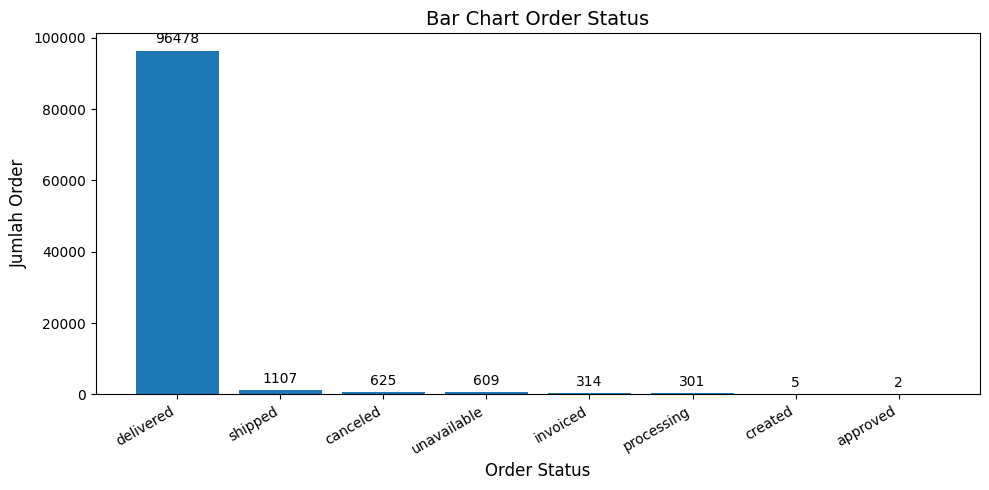

In [25]:
# hitung jumlah tiap status
status_counts = df_orders["order_status"].value_counts()

# plot
plt.figure(figsize=(10, 5))
bars = plt.bar(status_counts.index, status_counts.values)

# judul & label
plt.title("Bar Chart Order Status", fontsize=14)
plt.xlabel("Order Status", fontsize=12)
plt.ylabel("Jumlah Order", fontsize=12)

# rapihin label x
plt.xticks(rotation=30, ha='right')

# tambah nilai di atas tiap bar
plt.bar_label(bars, padding=3, fontsize=10)

# rapihin layout
plt.tight_layout()

plt.show()

In [26]:
delivery_time = df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
df_orders["delivery_time"] = round(delivery_time/86400)

In [27]:
df_orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99441,99441,99441,99441,99281,97658,96476,99441,96476.000000
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,12.517548
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,7.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,10.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,16.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,210.000000


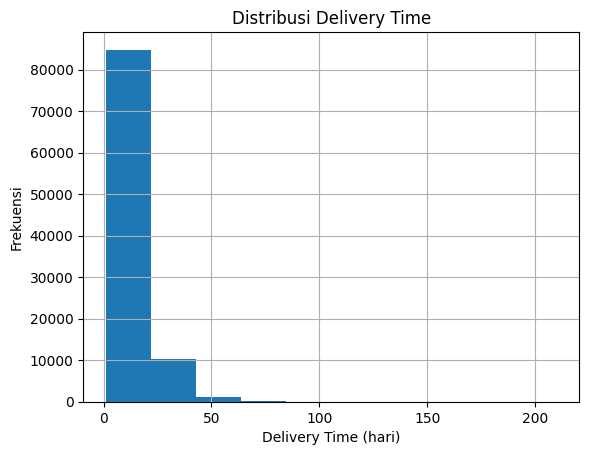

In [28]:
df_orders["delivery_time"].hist()

plt.title("Distribusi Delivery Time")
plt.xlabel("Delivery Time (hari)")
plt.ylabel("Frekuensi")

plt.show()

In [29]:
#@title Explore orders_payment_dataset

df_payments.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
70323,45e64bfe511bd5e24d56e200e29631b7,1,boleto,1,309.30
34097,c7fbf4fec3e516001a347b5b186d804a,1,credit_card,2,193.45
56842,0d103d6504de00ed0c99969517a9ad52,1,boleto,1,251.44
24100,cc6c9b89f70b32d7fe075718e0fc58e7,1,credit_card,3,236.00
102481,382e8f286f0c03a978e78372405fd3de,1,credit_card,5,216.15


In [30]:
df_payments.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103883,103883.000000,103883,103883.000000,103883.000000
unique,99437,NaN,4,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092681,NaN,2.853422,154.104831
std,NaN,0.706594,NaN,2.687054,217.495628
min,NaN,1.000000,NaN,1.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.800000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.840000


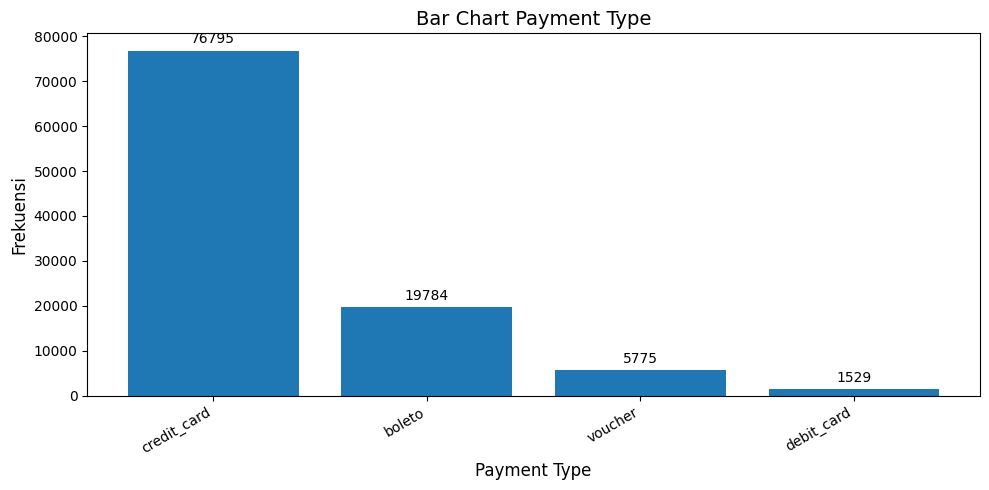

In [31]:
# hitung jumlah tiap jenis
type_counts = df_payments["payment_type"].value_counts()

# plot
plt.figure(figsize=(10, 5))
bars = plt.bar(type_counts.index, type_counts.values)

# judul & label
plt.title("Bar Chart Payment Type", fontsize=14)
plt.xlabel("Payment Type", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)

# rapihin label x
plt.xticks(rotation=30, ha='right')

# tambah nilai di atas tiap bar
plt.bar_label(bars, padding=3, fontsize=10)

# rapihin layout
plt.tight_layout()

plt.show()

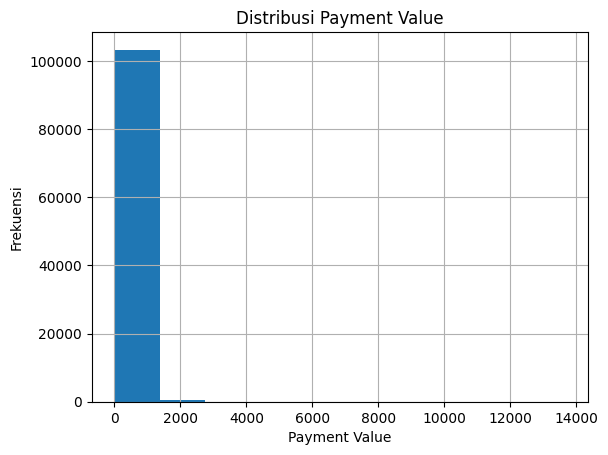

In [32]:
df_payments["payment_value"].hist()

plt.title("Distribusi Payment Value")
plt.xlabel("Payment Value")
plt.ylabel("Frekuensi")

plt.show()

**Insight:**
- Dataset pesanan memiliki timestamp dari tahun 2016 hingga tahun 2018.
- Mayoritas pesanan (sejumlah 96478 dari 99441) memiliki status "delivered".
- Dari histogram Distribusi Delivery Time, mayoritas pesanan memiliki waktu pengiriman kurang dair 50 hari.
- Sejumlah 76795 dari 99441 pembelian dibayar dengan menggunakan kartu kredit.
- Dari histogram Distribusi Payment Value, mayoritas pembelian bernilai kurang dari 2000.

In [33]:
#@title Explore orders_reviews_dataset

df_reviews.sample(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
28963,6ba0eedf99bd0d6796e05088924d4d89,b7e4aca3e798d20643faacb681272a9c,5,No Title,No Review Comment,2017-10-26,2017-10-26 14:59:41
81685,e1e1d1e755d5f1d8c75fe77d76af44dd,3910ae71e82730e3c560049e7637b3c2,5,Super recomendo,Entrega rápida,2018-05-03,2018-05-04 01:19:41
58113,756550cd0f0c26fa589881397382aba3,80d83b7a6c9a79612f4957850ec91be4,1,No Title,NÃO RECEBI O PRODUTO ATÉ HOJE,2018-04-21,2018-04-24 15:39:23
86393,056ff087f8e5fe614bc6cce3caa0c480,fd9ec02005605e0b338a29e03bc6eb30,5,No Title,O produto chegou muito antes do prazo e veio e...,2017-12-01,2017-12-01 17:20:55
84373,18e87ce15108fd10067d7e29759c8f1f,a8a737a6c936da9f10807e4c4262da72,3,No Title,No Review Comment,2018-08-18,2018-08-18 11:06:17


In [34]:
answer_time = df_reviews["review_answer_timestamp"] - df_reviews["review_creation_date"]
answer_time = answer_time.apply(lambda x: x.total_seconds())
df_reviews["answer_time"] = round(answer_time/86400)

In [35]:
df_reviews.describe(include="all")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,answer_time
count,99224,99224,99224.000000,99224,99224,99224,99224,99224.000000
unique,98410,98673,NaN,4528,36160,NaN,NaN,NaN
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,No Title,No Review Comment,NaN,NaN,NaN
freq,3,3,NaN,87656,58247,NaN,NaN,NaN
mean,NaN,NaN,4.086421,NaN,NaN,2018-01-12 20:49:23.948238336,2018-01-16 00:23:56.977938688,3.213658
min,NaN,NaN,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28,0.000000
25%,NaN,NaN,4.000000,NaN,NaN,2017-09-23 00:00:00,2017-09-27 01:53:27.249999872,1.000000
50%,NaN,NaN,5.000000,NaN,NaN,2018-02-02 00:00:00,2018-02-04 22:41:47.500000,2.000000
75%,NaN,NaN,5.000000,NaN,NaN,2018-05-16 00:00:00,2018-05-20 12:11:21.500000,3.000000
max,NaN,NaN,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35,519.000000


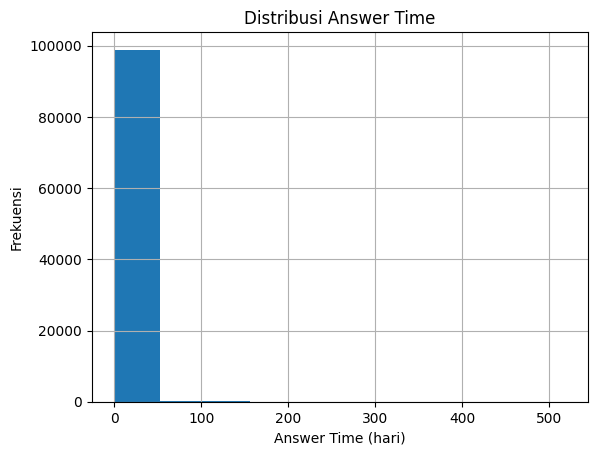

In [36]:
df_reviews["answer_time"].hist()

plt.title("Distribusi Answer Time")
plt.xlabel("Answer Time (hari)")
plt.ylabel("Frekuensi")

plt.show()

**Insight:**
- Review customer umumnya dijawab dalam waktu kurang dari atau sama dengan tiga hari yang menandakan kecepatan menjawab review cukup baik.

### Penggabungan semua dataset menjadi `df_all`

In [37]:
#Menggabungkan orders_dataset dengan order_payments_dataset
df_order_payments= pd.merge(
    left=df_orders,
    right=df_payments,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

df_order_payments.sample(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,payment_sequential,payment_type,payment_installments,payment_value
12423,b57278e94a17f53f5a91bb0aab49c397,8c812604bb36f468870e6b5c50d70531,delivered,2017-02-20 21:56:46,2017-02-22 03:05:08,2017-02-24 07:12:45,2017-04-20 12:08:20,2017-04-04,59.0,1.0,boleto,1.0,56.86
19970,0f0343a1e7cde1a1ee46f5c8274948d4,539b3638d0429be59e27871e1233b212,delivered,2017-11-17 19:51:09,2017-11-17 20:56:04,2017-11-20 21:21:46,2017-12-06 23:42:22,2017-12-15,19.0,1.0,credit_card,1.0,37.82
32972,3987b835c34fa14457d123796b99ba27,50edf1bb01f965f14bee7527c3bed42f,delivered,2018-02-25 12:52:37,2018-02-25 13:07:51,2018-02-28 19:32:45,2018-03-18 17:21:22,2018-03-27,21.0,1.0,credit_card,10.0,232.95
27698,6d9ae94dabe435d638bfc80834e79b4a,5a1fb4a5f5bbc3c9df401e607b0f1ddc,delivered,2018-01-24 11:40:18,2018-01-24 15:08:07,2018-01-26 14:12:34,2018-02-02 14:35:10,2018-02-16,9.0,1.0,credit_card,6.0,228.66
71332,04378b376807e5fbc797362f9e06ea2d,59a972de56e32837ef21cada8664ddc2,delivered,2018-04-15 11:54:06,2018-04-15 12:10:45,2018-04-16 19:27:40,2018-04-24 19:36:36,2018-05-11,9.0,1.0,credit_card,1.0,45.23


In [38]:
#Menggabungkan order_payments_dataset dengan order_reviews_dataset
df_order_payments_reviews= pd.merge(
    left=df_order_payments,
    right=df_reviews,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

df_order_payments_reviews.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,answer_time
90520,b9bf94ff5b1f62b2a075bca13eb69bdc,8c3311e2986b4d0585b9e03aca32d64d,delivered,2018-05-02 18:51:12,2018-05-03 18:55:33,2018-05-04 14:56:00,2018-05-14 16:19:02,2018-05-30,12.0,1.0,credit_card,3.0,213.79,a417b90f39a353b9845b5ab9df7012e8,5.0,No Title,No Review Comment,2018-05-15,2018-05-20 13:27:27,6.0
4746,04e452498b75f049f617f5ed7ffc0633,52ebfe7b40ff6cbe2db79c566f36e6bb,delivered,2018-05-22 23:30:07,2018-05-22 23:57:56,2018-05-23 20:23:00,2018-05-24 21:18:24,2018-06-06,2.0,1.0,credit_card,7.0,233.92,55199a6d5cc80ab954d74fd0c0593624,5.0,No Title,No Review Comment,2018-05-25,2018-05-27 14:19:53,3.0
97489,d8d5b2d660ff0d4f9391b823cf3d6b3c,904a7071bc6fff469bf6c0ae74017a7b,delivered,2018-02-21 22:38:45,2018-02-21 22:50:42,2018-02-22 18:53:40,2018-03-06 20:52:44,2018-03-20,13.0,1.0,credit_card,2.0,166.50,0bf5c41b3587018d0367b47b6bc6d76e,1.0,No Title,"Comprei dois tapetes juntos e só recebi um, te...",2018-03-07,2018-03-08 05:38:25,1.0
65130,dd29da5b9bd433b33344a6263b0bb3ae,5ee182d6d7f615689babec22e9fec9f3,delivered,2018-03-03 17:27:37,2018-03-03 18:00:22,2018-03-05 22:08:21,2018-03-06 14:46:39,2018-03-15,3.0,1.0,credit_card,8.0,199.79,a6dcbe0e558b48cac2a2c41534993da1,5.0,No Title,No Review Comment,2018-03-07,2018-03-09 18:35:48,3.0
74662,aee2f64144baa740663e8cd823582528,40145af8781e070b66bcbcd10099f420,delivered,2017-12-28 12:09:36,2017-12-28 12:31:12,2017-12-28 20:23:40,2018-01-03 17:38:56,2018-01-17,6.0,1.0,credit_card,1.0,190.06,79742453ad10cf1f89150dce601ec986,5.0,No Title,No Review Comment,2018-01-04,2018-01-07 13:49:00,4.0


In [39]:
#Menggabungkan order_payments_reviews_dataset dengan customer_dataset
df_all= pd.merge(
    left=df_order_payments_reviews,
    right=df_customer,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

df_all.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,payment_sequential,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,answer_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
87419,b4a90f27b4f23868d8fc84e9dceb125b,e3fa22e3272e681790daa32be5a29243,delivered,2018-08-14 00:34:17,2018-08-15 03:35:19,2018-08-15 15:10:00,2018-08-22 14:38:42,2018-08-23,9.0,1.0,...,1.0,Não recebi o produto,Até o momento nem recebi o produto nem mesmo o...,2018-08-23,2018-08-23 18:20:00,1.0,55670eb40d8c326eea6c05ce30ed0fcf,85860,foz do iguacu,PR
28748,0d54c04be25f0f72f2f63f5b93d0bca7,ea66ab419deb40209a51853f56ab42db,delivered,2018-05-01 17:33:29,2018-05-01 17:52:58,2018-05-02 15:13:00,2018-05-04 23:32:28,2018-05-15,3.0,1.0,...,4.0,No Title,No Review Comment,2018-05-05,2018-05-06 19:24:22,2.0,9df662fbc5d5bf77a06b55709bdf25a2,3334,sao paulo,SP
46685,6055deb46d2d0a116e20655c435797e3,3bd7644308c830aa185f06e30c03a4f1,delivered,2017-07-30 19:38:19,2017-07-30 19:50:08,2017-07-31 20:17:47,2017-08-07 21:33:21,2017-08-22,8.0,1.0,...,2.0,No Title,Achei que o produto era de melhor qualidade.,2017-08-08,2017-08-10 00:01:23,2.0,ca17e3112344548df614525152da71d6,38290,carneirinho,MG
34328,dcd55caf6dcb4c4a54e6f09eecdb4822,338ceb7a4e121b2cf002f41b325d76d4,delivered,2017-10-12 15:03:54,2017-10-13 10:28:11,2017-10-13 16:46:16,2017-10-17 17:50:00,2017-10-31,5.0,1.0,...,5.0,No Title,Entrega no prazo excelente recomendo,2017-10-18,2017-10-20 18:10:08,3.0,88945f497a68b0df94f5384be8b3e5ef,12460,campos do jordao,SP
48427,90195b2be816e11d2c854069f663f7f0,879dbf04bb9f856512c1c0e43290157f,delivered,2017-11-28 23:10:29,2017-11-28 23:37:46,2017-12-01 21:29:04,2017-12-26 20:33:22,2017-12-18,28.0,1.0,...,1.0,No Title,Não gostei,2017-12-19,2017-12-21 05:46:44,2.0,8037f9afee889e6091a3bd0d0a0af778,2849,sao paulo,SP


In [40]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104478 entries, 0 to 104477
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       104478 non-null  object        
 1   customer_id                    104478 non-null  object        
 2   order_status                   104478 non-null  object        
 3   order_purchase_timestamp       104478 non-null  datetime64[ns]
 4   order_approved_at              104302 non-null  datetime64[ns]
 5   order_delivered_carrier_date   102580 non-null  datetime64[ns]
 6   order_delivered_customer_date  101324 non-null  datetime64[ns]
 7   order_estimated_delivery_date  104478 non-null  datetime64[ns]
 8   delivery_time                  101324 non-null  float64       
 9   payment_sequential             104474 non-null  float64       
 10  payment_type                   104474 non-null  object        
 11  

In [41]:
df_all.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,payment_sequential,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,answer_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,104478,104478,104478,104478,104302,102580,101324,104478,101324.000000,104474.000000,...,103678.000000,103678,103678,103678,103678,103678.000000,104478,104478,104478,104478
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4528,36160,NaN,NaN,NaN,96096,14994,4119,27
top,fa65dad1b0e818e3ccc5cb0e39231352,9af2372a1e49340278e7c1ef8d749f34,delivered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,No Title,No Review Comment,NaN,NaN,NaN,9a736b248f67d166d2fbb006bcb877c3,22790,sao paulo,SP
freq,29,29,101326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,91682,60862,NaN,NaN,NaN,33,143,16326,43865
mean,NaN,NaN,NaN,2017-12-29 13:28:28.739935744,2017-12-29 23:18:25.921688832,2018-01-03 02:41:08.265938688,2018-01-12 18:39:04.768889856,2018-01-22 08:49:37.913053440,12.536112,1.093382,...,4.083856,NaN,NaN,2018-01-11 09:39:10.462007552,2018-01-14 13:25:17.502826240,3.221686,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,1.000000,...,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2017-09-09 14:41:25,2017-09-10 10:30:25.500000,2017-09-13 21:32:30,2017-09-21 21:16:31.249999872,2017-09-29 00:00:00,7.000000,1.000000,...,4.000000,NaN,NaN,2017-09-21 00:00:00,2017-09-23 22:17:40.500000,1.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2018-01-17 09:03:10,2018-01-17 12:50:02,2018-01-23 12:14:49.500000,2018-02-01 00:28:11,2018-02-14 00:00:00,10.000000,1.000000,...,5.000000,NaN,NaN,2018-01-31 00:00:00,2018-02-03 02:03:29.500000,2.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2018-05-03 13:18:48,2018-05-03 16:30:25.750000128,2018-05-07 14:50:15,2018-05-15 13:42:43.249999872,2018-05-25 00:00:00,16.000000,1.000000,...,5.000000,NaN,NaN,2018-05-15 00:00:00,2018-05-17 13:13:35.750000128,3.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,210.000000,29.000000,...,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35,519.000000,NaN,NaN,NaN,NaN


In [42]:
df_all.to_csv("all_data.csv", index=False)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren penjualan secara bulanan (Month-over-Month) sepanjang tahun 2017?

In [43]:
#agregasi data penjualan dan revenue secara bulanan

df_monthly_sales = df_all.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "payment_value": "sum"
})

df_monthly_sales.index = df_monthly_sales.index.strftime('%Y-%m')
df_monthly_sales = df_monthly_sales.reset_index()

df_monthly_sales.rename(columns={
    "order_purchase_timestamp": "order_month",
    "order_id": "order_count",
    "payment_value": "revenue"
}, inplace=True)

df_monthly_sales.head()

/tmp/ipykernel_3090/4267981285.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_sales = df_all.resample(rule='M', on='order_purchase_timestamp').agg({


,order_month,order_count,revenue
0,2016-09,4,252.24
1,2016-10,324,59271.30
2,2016-11,0,0.00
3,2016-12,1,19.62
4,2017-01,800,139459.77


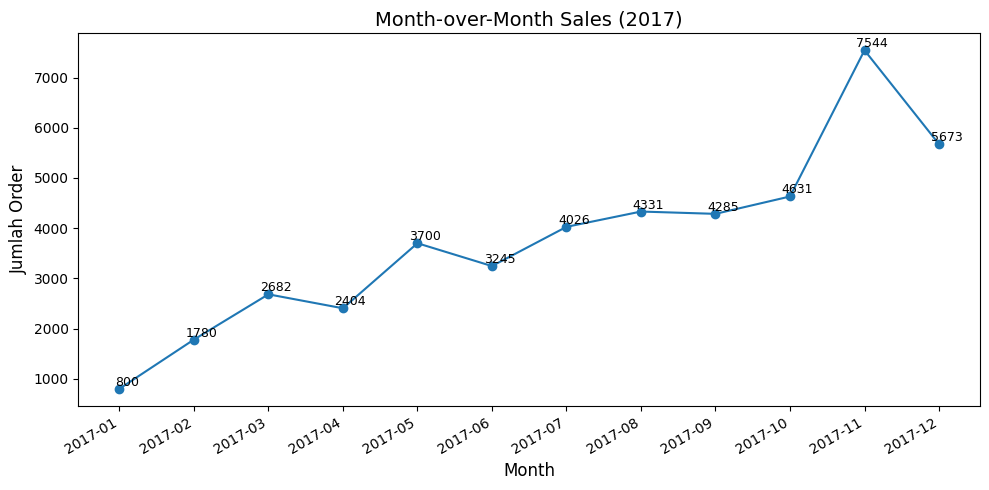

In [44]:
#@title Jumlah penjualan per bulan sepanjang 2017

# filter data tahun 2017
df_monthly_2017 = df_monthly_sales[df_monthly_sales["order_month"].str.startswith("2017")]

# plot
plt.figure(figsize=(10, 5))

plt.plot(df_monthly_2017["order_month"], df_monthly_2017["order_count"], marker='o')

for i, value in enumerate(df_monthly_2017["order_count"]):
    plt.text(i + 0.1, value, str(value), ha='center', va='bottom', fontsize=9)

plt.title("Month-over-Month Sales (2017)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Jumlah Order", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

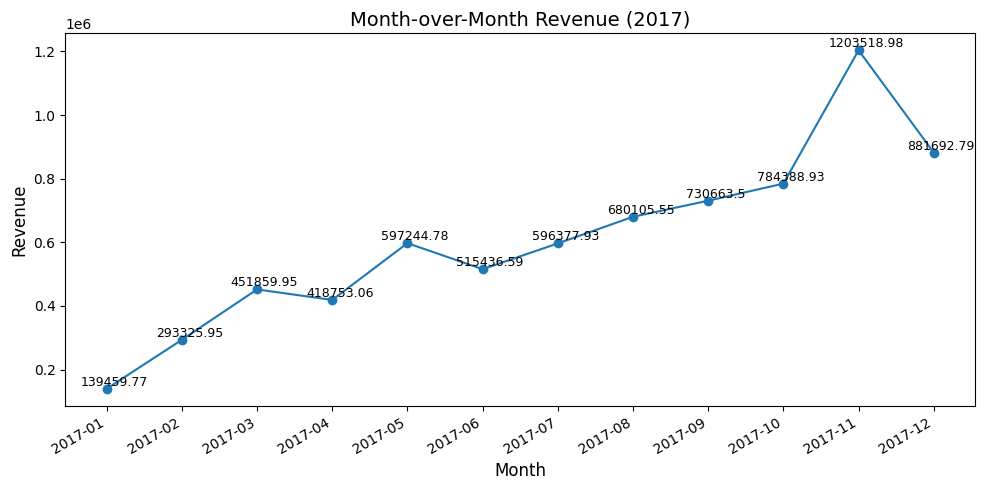

In [45]:
#@title Revenue per bulan sepanjang 2017

# plot
plt.figure(figsize=(10, 5))

plt.plot(df_monthly_2017["order_month"], df_monthly_2017["revenue"], marker='o')

for i, value in enumerate(df_monthly_2017["revenue"]):
    plt.text(i + 0.1, value, str(value), ha='center', va='bottom', fontsize=9)

plt.title("Month-over-Month Revenue (2017)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Insight:**
- Jumlah penjualan dan revenue terendah terjadi pada Januari 2017, dengan total 800 pesanan dan revenue sebesar 139.459,77.
- Puncak performa terjadi pada November 2017, dengan total 7.544 pesanan dan revenue sebesar 1.203.518,98, menjadikannya bulan dengan performa penjualan tertinggi sepanjang tahun.
- Secara umum, penjualan dan revenue menunjukkan tren peningkatan yang konsisten sepanjang 2017.
- Pola ini mengindikasikan adanya pertumbuhan permintaan yang positif sepanjang tahun, dengan momentum penjualan yang semakin kuat menuju akhir tahun.

### Pertanyaan 2: Bagaimana tingkat kepuasan pelanggan terhadap produk sepanjang yahun 2017?


In [46]:
#agregasi review secara bulanan

# filter data review tahun 2017
df_review_2017 = df_all[df_all["review_creation_date"].dt.year == 2017].copy()

# agregasi bulanan: jumlah review per bulan dan rata-rata review score per bulan
df_monthly_review = df_review_2017.resample(rule='M', on='review_creation_date').agg({
    "order_id": "nunique",
    "review_score": "mean"
})

df_monthly_review.index = df_monthly_review.index.strftime('%Y-%m')
df_monthly_review = df_monthly_review.reset_index()

df_monthly_review.rename(columns={
    "review_creation_date": "review_month",
    "order_id": "review_count",
    "review_score": "avg_review_score"
}, inplace=True)

# bulatkan rata-rata review ke 2 angka desimal
df_monthly_review["avg_review_score"] = df_monthly_review["avg_review_score"].round(2)

df_monthly_review.head()

/tmp/ipykernel_3090/2838033065.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_review = df_review_2017.resample(rule='M', on='review_creation_date').agg({


,review_month,review_count,avg_review_score
0,2017-01,237,4.39
1,2017-02,1405,4.29
2,2017-03,2468,4.04
3,2017-04,2049,4.04
4,2017-05,3686,4.06


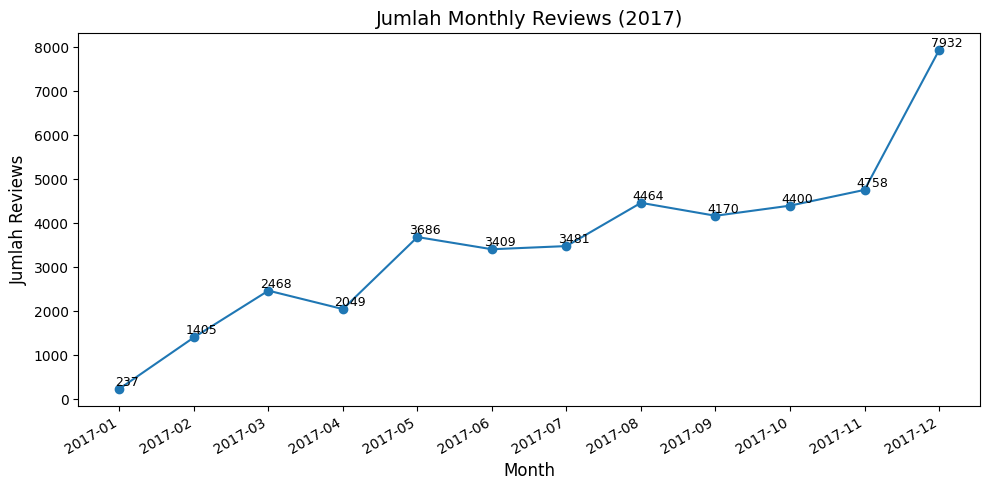

In [47]:
#@title Jumlah review per bulan sepanjang 2017

# plot
plt.figure(figsize=(10, 5))

plt.plot(df_monthly_review["review_month"], df_monthly_review["review_count"], marker='o')

for i, value in enumerate(df_monthly_review["review_count"]):
    plt.text(i + 0.1, value, str(value), ha='center', va='bottom', fontsize=9)

plt.title("Jumlah Monthly Reviews (2017)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Jumlah Reviews", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

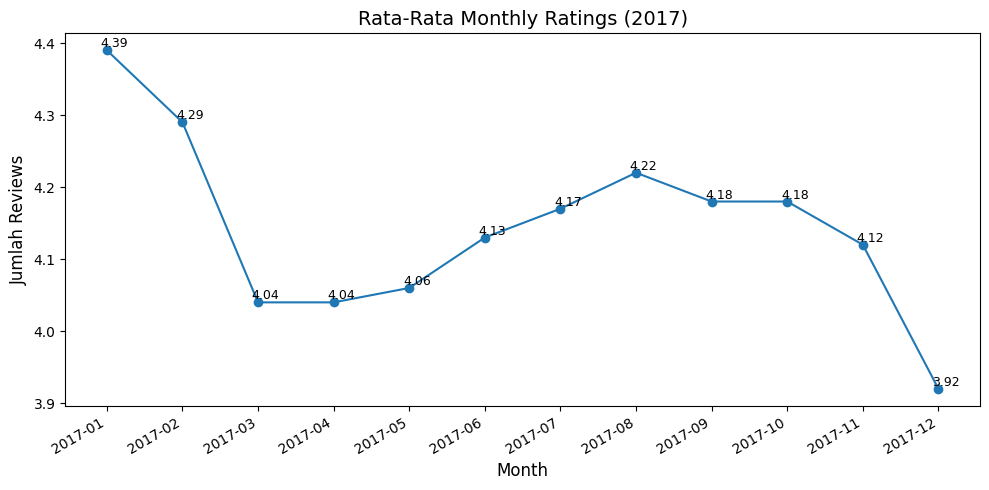

In [48]:
#@title Rata-rata rating per bulan sepanjang 2017

# plot
plt.figure(figsize=(10, 5))

plt.plot(df_monthly_review["review_month"], df_monthly_review["avg_review_score"], marker='o')

for i, value in enumerate(df_monthly_review["avg_review_score"]):
    plt.text(i + 0.1, value, str(value), ha='center', va='bottom', fontsize=9)

plt.title("Rata-Rata Monthly Ratings (2017)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Jumlah Reviews", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [49]:
# =========================
# Distribusi Rating Review (2017)
# =========================

df_review_distribution_2017 = df_review_2017["review_score"].value_counts().sort_index().reset_index()

df_review_distribution_2017.columns = ["review_score", "review_count"]

df_review_distribution_2017.head()

,review_score,review_count
0,1.0,4894
1,2.0,1449
2,3.0,3768
3,4.0,8883
4,5.0,26076


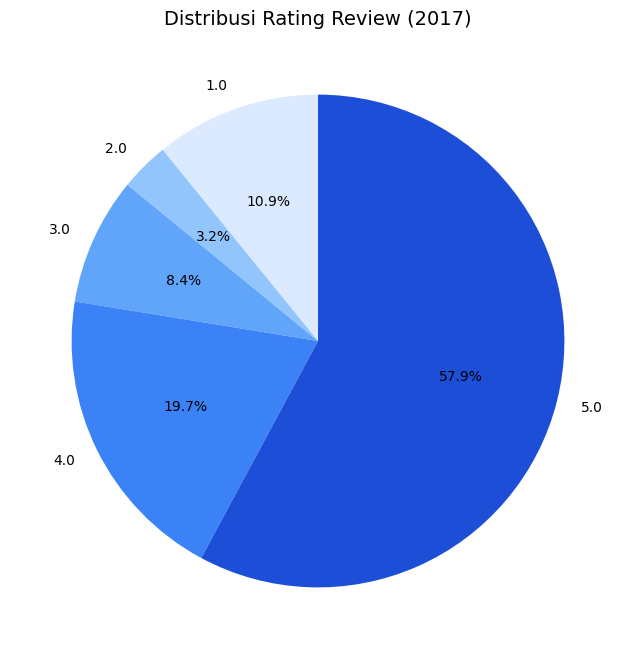

In [50]:
#@title Pie Chart Distribusi Rating Review (2017)
plt.figure(figsize=(8, 8))

# color palette
colors = ["#dbeafe", "#93c5fd", "#60a5fa", "#3b82f6", "#1d4ed8"]

plt.pie(
    df_review_distribution_2017["review_count"],
    labels=df_review_distribution_2017["review_score"],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title("Distribusi Rating Review (2017)", fontsize=14)
plt.show()

**Insight:**
- Jumlah review pelanggan cenderung meningkat sepanjang 2017 dan mencapai puncaknya pada Desember 2017, menunjukkan bahwa volume transaksi lebih tinggi diikuti oleh peningkatan pelanggan dalam memberikan ulasan.
- Meskipun jumlah review meningkat, rata-rata rating pelanggan justru menunjukkan tren penurunan bertahap sepanjang tahun dan mencapai titik terendah pada Desember 2017 (3,92). Pola ini mengindikasikan bahwa peningkatan volume transaksi belum diimbangi dengan konsistensi kualitas pengalaman pelanggan.
- Distribusi rating masih didominasi oleh ulasan positif, di mana rating 4 dan 5 mencakup 77,6% dari total review. Hal ini menunjukkan bahwa secara umum pelanggan masih merasa puas terhadap pengalaman berbelanja.
- Namun, proporsi rating rendah (1 dan 2) mencapai 14,1%, yang mengindikasikan masih terdapat porsi pelanggan yang mengalami pengalaman kurang memuaskan dalam jumlah yang cukup signifikan.


### Pertanyaan 3: Bagaimana pengaruh faktor operasional transaksi terhadap kepuasan pelanggan sepanjang tahun 2017?

In [56]:
# filter data tahun 2017
df_operational_2017 = df_all[df_all["order_purchase_timestamp"].dt.year == 2017].copy()

# agregasi bulanan
monthly_operational_df = df_operational_2017.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",          # jumlah order
    "payment_value": "sum",        # jumlah nilai transaksi
    "delivery_time": "mean",        # rata-rata waktu pengiriman
    "answer_time": "mean",          # rata-rata waktu respons review
    "review_score": "mean"          # rata-rata kepuasan pelanggan
})

monthly_operational_df.index = monthly_operational_df.index.strftime('%Y-%m')
monthly_operational_df = monthly_operational_df.reset_index()

monthly_operational_df.rename(columns={
    "order_purchase_timestamp": "order_month",
    "order_id": "order_count",
    "payment_value": "avg_payment_value",
    "delivery_time": "avg_delivery_time",
    "answer_time": "avg_answer_time",
    "review_score": "avg_review_score"
}, inplace=True)

# rapikan angka desimal
monthly_operational_df["avg_payment_value"] = monthly_operational_df["avg_payment_value"].round(2)
monthly_operational_df["avg_delivery_time"] = monthly_operational_df["avg_delivery_time"].round(2)
monthly_operational_df["avg_answer_time"] = monthly_operational_df["avg_answer_time"].round(2)
monthly_operational_df["avg_review_score"] = monthly_operational_df["avg_review_score"].round(2)

monthly_operational_df.head()

/tmp/ipykernel_3090/4215074453.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_operational_df = df_operational_2017.resample(rule='M', on='order_purchase_timestamp').agg({


,order_month,order_count,avg_payment_value,avg_delivery_time,avg_answer_time,avg_review_score
0,2017-01,800,139459.77,12.79,2.75,4.11
1,2017-02,1780,293325.95,13.28,3.94,4.02
2,2017-03,2682,451859.95,13.06,4.42,4.08
3,2017-04,2404,418753.06,14.94,4.61,4.01
4,2017-05,3700,597244.78,11.36,4.05,4.14


In [54]:
# Correlation Matrix
operational_corr_df = monthly_operational_df[
    ["order_count", "avg_payment_value", "avg_delivery_time", "avg_answer_time", "avg_review_score"]
].corr()

operational_corr_df

,order_count,avg_payment_value,avg_delivery_time,avg_answer_time,avg_review_score
order_count,1.000000,-0.359770,0.229509,-0.360291,-0.291506
avg_payment_value,-0.359770,1.000000,0.234010,0.252541,-0.167660
avg_delivery_time,0.229509,0.234010,1.000000,0.092566,-0.895072
avg_answer_time,-0.360291,0.252541,0.092566,1.000000,-0.090980
avg_review_score,-0.291506,-0.167660,-0.895072,-0.090980,1.000000


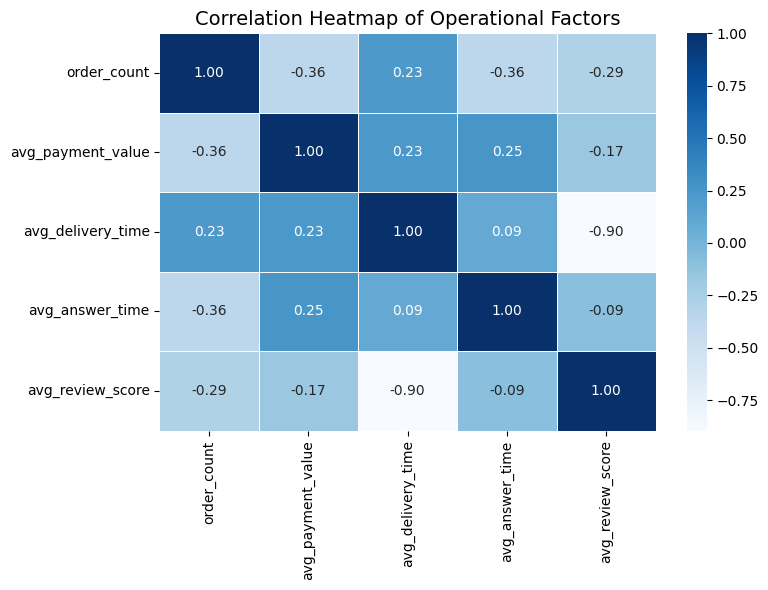

In [57]:
#@title Correlation Heatmap Faktor Operasional

plt.figure(figsize=(8, 6))

sns.heatmap(
    operational_corr_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Operational Factors", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**
- Secara umum, sebagian besar faktor operasional transaksi tidak menunjukkan hubungan yang kuat terhadap rata-rata kepuasan pelanggan. Hal ini terlihat dari nilai korelasi order_count, avg_payment_value, dan avg_answer_time terhadap avg_review_score yang relatif rendah (|r| < 0,5), sehingga ketiga faktor tersebut cenderung bukan penentu utama perubahan kepuasan pelanggan.
- Rata-rata waktu pengiriman (avg_delivery_time) merupakan faktor yang memiliki hubungan paling kuat terhadap kepuasan pelanggan, dengan korelasi negatif yang sangat tinggi sebesar -0,91.
- Korelasi negatif yang kuat ini menunjukkan bahwa semakin lama waktu pengiriman, rata-rata skor kepuasan pelanggan cenderung semakin rendah. Sebaliknya, semakin cepat pesanan diterima pelanggan, tingkat kepuasan cenderung meningkat.

## Analisis Lanjutan: RFM Analysis sepanjang 2017

Analisis ini dilakukan untuk mendapatkan segmentasi pelanggan pada tahun 2017.

Fokus analisis RFM pada notebook ini adalah churn rate customer (tingkat perputaran pelanggan) sehingga aspek Recency menjadi aspek utama diikuti Frequency dan terakhir Monetary

In [58]:
#@title Persiapan data
# filter data tahun 2017
df_rfm_2017 = df_all[df_all["order_purchase_timestamp"].dt.year == 2017].copy()

# ambil tanggal referensi (tanggal transaksi terakhir di 2017)
recent_date = df_rfm_2017["order_purchase_timestamp"].max()

# hitung RFM per customer
rfm_df = df_rfm_2017.groupby("customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days,  # Recency
    "order_id": "nunique",                                              # Frequency
    "payment_value": "sum"                                              # Monetary
})

# rename kolom
rfm_df.rename(columns={
    "order_purchase_timestamp": "Recency",
    "order_id": "Frequency",
    "payment_value": "Monetary"
}, inplace=True)

# rapikan monetary
rfm_df["Monetary"] = rfm_df["Monetary"].round(2)

rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000f46a3911fa3c0805444483337064,296,1,86.22
1,0000f6ccb0745a6a4b88665a16c9f078,80,1,43.62
2,0004aac84e0df4da2b147fca70cf8255,47,1,196.89
3,0005e1862207bf6ccc02e4228effd9a0,301,1,150.12
4,0006fdc98a402fceb4eb0ee528f6a8d4,166,1,29.00


In [60]:
#@title RFM Ranking, Scoring, and Segmentation

# Rank customers berdasarkan RFM
# Recency: semakin kecil semakin baik:descending=False
# Frequency: semakin besar semakin baik: descending=True
# Monetary: lsemakin besar semakin baik: descending=True


rfm_df["R_rank"] = rfm_df["Recency"].rank(ascending=False)
rfm_df["F_rank"] = rfm_df["Frequency"].rank(ascending=True)
rfm_df["M_rank"] = rfm_df["Monetary"].rank(ascending=True)

# Normalisai ranks ke 0-100
rfm_df["R_rank_norm"] = (rfm_df["R_rank"] / rfm_df["R_rank"].max()) * 100
rfm_df["F_rank_norm"] = (rfm_df["F_rank"] / rfm_df["F_rank"].max()) * 100
rfm_df["M_rank_norm"] = (rfm_df["M_rank"] / rfm_df["M_rank"].max()) * 100

# Drop raw ranks
rfm_df.drop(columns=["R_rank", "F_rank", "M_rank"], inplace=True)

rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,0000f46a3911fa3c0805444483337064,296,1,86.22,7.404524,48.5645,40.352984
1,0000f6ccb0745a6a4b88665a16c9f078,80,1,43.62,63.863449,48.5645,12.094800
2,0004aac84e0df4da2b147fca70cf8255,47,1,196.89,75.146534,48.5645,77.905886
3,0005e1862207bf6ccc02e4228effd9a0,301,1,150.12,6.434884,48.5645,66.773042
4,0006fdc98a402fceb4eb0ee528f6a8d4,166,1,29.00,37.050096,48.5645,2.928191


In [66]:
#@title RFM Scoring
rfm_df["RFM_Score"] = (
    0.50 * rfm_df["R_rank_norm"] + #aspek utama sehingga bobotnya terbesar
    0.30 * rfm_df["F_rank_norm"] +
    0.20 * rfm_df["M_rank_norm"]
)

rfm_df["RFM_Score"] = rfm_df["RFM_Score"] * 0.05
rfm_df = rfm_df.round(2)

rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,0000f46a3911fa3c0805444483337064,296,1,86.22,7.40,48.56,40.35,1.32,Low Value Customers
1,0000f6ccb0745a6a4b88665a16c9f078,80,1,43.62,63.86,48.56,12.09,2.45,Low Value Customers
2,0004aac84e0df4da2b147fca70cf8255,47,1,196.89,75.15,48.56,77.91,3.39,Medium Value Customers
3,0005e1862207bf6ccc02e4228effd9a0,301,1,150.12,6.43,48.56,66.77,1.56,Low Value Customers
4,0006fdc98a402fceb4eb0ee528f6a8d4,166,1,29.00,37.05,48.56,2.93,1.68,Lost Customers


In [69]:
#@title RFM Segmentation
rfm_df["Customer_segment"] = np.where(
    rfm_df["RFM_Score"] > 4.0, "High Value Customers",
    np.where(
        rfm_df["RFM_Score"] > 3.0, "Medium Value Customers",
        np.where(
            rfm_df["RFM_Score"] > 1.6, "Low Value Customers",
            "Lost Customers"
        )
    )
)

rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,0000f46a3911fa3c0805444483337064,296,1,86.22,7.40,48.56,40.35,1.32,Lost Customers
1,0000f6ccb0745a6a4b88665a16c9f078,80,1,43.62,63.86,48.56,12.09,2.45,Low Value Customers
2,0004aac84e0df4da2b147fca70cf8255,47,1,196.89,75.15,48.56,77.91,3.39,Medium Value Customers
3,0005e1862207bf6ccc02e4228effd9a0,301,1,150.12,6.43,48.56,66.77,1.56,Lost Customers
4,0006fdc98a402fceb4eb0ee528f6a8d4,166,1,29.00,37.05,48.56,2.93,1.68,Low Value Customers


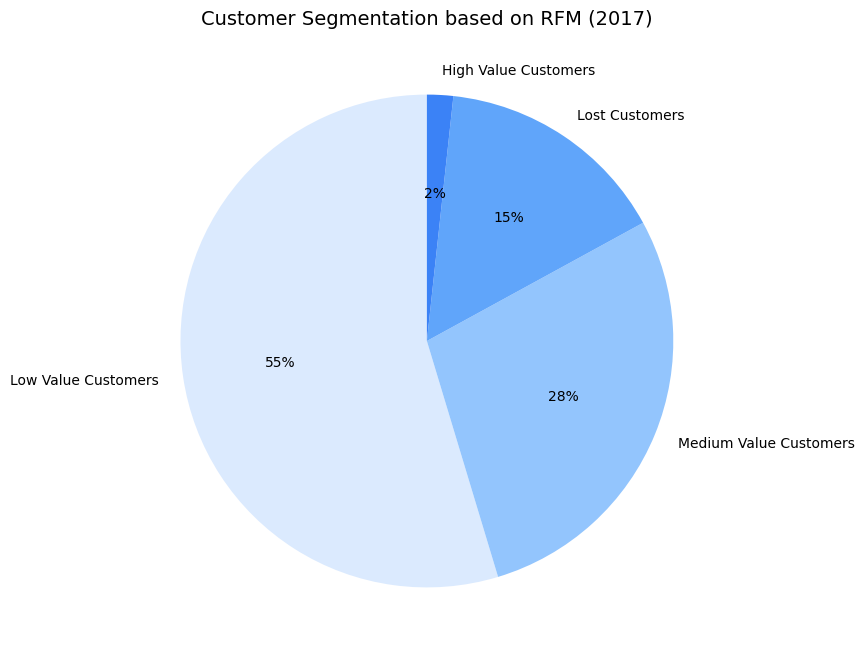

In [70]:
#@title Pie Chart Segmentasi Customer

plt.figure(figsize=(8, 8))

colors = ["#dbeafe", "#93c5fd", "#60a5fa", "#3b82f6", "#1d4ed8"]

plt.pie(
    rfm_df["Customer_segment"].value_counts(),
    labels=rfm_df["Customer_segment"].value_counts().index,
    autopct="%.0f%%",
    startangle=90,
    colors=colors
)

plt.title("Customer Segmentation based on RFM (2017)", fontsize=14)
plt.show()

**Insight:**
- Mayoritas pelanggan masuk memiliki skor yang cukup rendah yaitu kategori low value customer dan lost customer yaitu sebesar 70%. Hal ini menunjukkan  sebagian besar  pelanggan memiliki kontribusi transaksi yang rendah atau mulai tidak aktif.
- Hanya 30% pelanggan yang masuk ke dalam kategori medium to high value customer (pelanggan yang memiliki skor RPM lebih tinggi)
- Penjualan didominasi oleh pelanggan dengan churn rate rendah, sehingga ada peluang besar untuk meningkatkan nilai pelanggan melalui aktivasi ulang pada segmen rendah serta retensi yang lebih terarah pada segmen bernilai tinggi.

## Conclusion

- Conclution pertanyaan 1: Penjualan sepanjang 2017 menunjukkan tren pertumbuhan bulanan yang positif, dengan performa terendah di awal tahun dan puncak penjualan terjadi pada November 2017. Hal ini menunjukkan adanya peningkatan permintaan yang konsisten sepanjang tahun, terutama menjelang akhir tahun.
- Conclution pertanyaan 2: Meskipun mayoritas pelanggan masih memberikan ulasan positif sepanjang 2017, rata-rata tingkat kepuasan menunjukkan tren penurunan secara bertahap. Hal ini mengindikasikan bahwa peningkatan volume transaksi belum sepenuhnya diimbangi dengan kualitas pengalaman pelanggan yang konsisten.
- Conclution pertanyaan 3: Dari seluruh faktor operasional yang dianalisis, waktu pengiriman merupakan faktor yang paling berpengaruh terhadap kepuasan pelanggan. Semakin lama waktu pengiriman, semakin rendah tingkat kepuasan pelanggan, sehingga optimasi proses pengiriman menjadi prioritas utama untuk meningkatkan customer experience.

## Referensi
https://www.geeksforgeeks.org/data-analysis/rfm-analysis-analysis-using-python/

https://github.com/dicodingacademy/a555-Project-Structure